In [2]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = -sp.I * (2*s + 1) / 2 + sp.I * (2*N + 1) / 2
            den = (s + 2) * (s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = -sp.I * (2*s + 1) / 2 + sp.I * (2*N + 1) / 2
            den = (s + 2) * (s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="x"):
    leading = 'a0' if N % 2 == 0 else 'a1'
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(f"{var if s==1 else '1'}")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = {leading}  ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=1/4

f_1(x) = a1  (x)
f_2(x) = a0  (1 + (i)x^2)
f_3(x) = a1  (x + (i/3)x^3)
f_4(x) = a0  (1 + (2*i)x^2 + (-1/3)x^4)
f_5(x) = a1  (x + (2*i/3)x^3 + (-1/15)x^5)
f_6(x) = a0  (1 + (3*i)x^2 + (-1)x^4 + (-i/15)x^6)
f_7(x) = a1  (x + (i)x^3 + (-1/5)x^5 + (-i/105)x^7)


In [3]:
import sympy as sp

def build_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, N, 2):  
            num = sp.I*(2*s + 1)/2 - sp.I*(2*N + 1)/2   
            den = (s + 2)*(s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, N, 2):  
            num = sp.I*(2*s + 1)/2 - sp.I*(2*N + 1)/2   
            den = (s + 2)*(s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])

    return coeffs, leading

def normalized_coeffs_sympy(N):
    coeffs, leading = build_coeffs_sympy(N)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs], leading

def poly_string_sympy(N, var="x"):
    coeffs_norm, leading = normalized_coeffs_sympy(N)
    leading_name = 'a0' if N % 2 == 0 else 'a1'
    terms = []
    for s, cs in enumerate(coeffs_norm):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(var if s == 1 else "1")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    return (f"f_{N}({var}) = {leading_name}  (" + " + ".join(terms) + ")").replace("I","i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=-1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=-1/4

f_1(x) = a1  (x)
f_2(x) = a0  (1 + (-i)x^2)
f_3(x) = a1  (x + (-i/3)x^3)
f_4(x) = a0  (1 + (-2*i)x^2 + (-1/3)x^4)
f_5(x) = a1  (x + (-2*i/3)x^3 + (-1/15)x^5)
f_6(x) = a0  (1 + (-3*i)x^2 + (-1)x^4 + (i/15)x^6)
f_7(x) = a1  (x + (-i)x^3 + (-1/5)x^5 + (i/105)x^7)


In [4]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = -sp.I * (2*s + 3) / 2 + sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = -sp.I * (2*s + 3) / 2 + sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="x"):
    leading = 'a0' if N % 2 == 0 else 'a1'
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(f"{var if s==1 else '1'}")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = {leading} ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=1, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=1, beta=1/4

f_1(x) = a1 (x)
f_2(x) = a0 (1 + (i/3)x^2)
f_3(x) = a1 (x + (i/6)x^3)
f_4(x) = a0 (1 + (2*i/3)x^2 + (-1/15)x^4)
f_5(x) = a1 (x + (i/3)x^3 + (-1/45)x^5)
f_6(x) = a0 (1 + (i)x^2 + (-1/5)x^4 + (-i/105)x^6)
f_7(x) = a1 (x + (i/2)x^3 + (-1/15)x^5 + (-i/420)x^7)


In [5]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = sp.I * (2*s + 3) / 2 - sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = -sp.I * (2*s + 3) / 2 + sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="x"):
    leading = 'a0' if N % 2 == 0 else 'a1'
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(f"{var if s==1 else '1'}")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = {leading} ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=1, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=1, beta=1/4

f_1(x) = a1 (x)
f_2(x) = a0 (1 + (-i/3)x^2)
f_3(x) = a1 (x + (i/6)x^3)
f_4(x) = a0 (1 + (-2*i/3)x^2 + (-1/15)x^4)
f_5(x) = a1 (x + (i/3)x^3 + (-1/45)x^5)
f_6(x) = a0 (1 + (-i)x^2 + (-1/5)x^4 + (i/105)x^6)
f_7(x) = a1 (x + (i/2)x^3 + (-1/15)x^5 + (-i/420)x^7)


Polinomios asociados a la ec. hipergeometrica confluente

In [6]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0')  # ya no necesitamos a1

    coeffs = [sp.Integer(0)] * (N + 1)
    coeffs[0] = leading

    a_tr = -2*sp.I*(N*(N-1) + N + sp.Rational(3,4))

    for s in range(0, N):  # paso 1
        num = -(s*(s-1) + s + sp.Rational(3,4) - 2*sp.I*((N*(N-1)) + N+ sp.Rational(3,4)))
        den = (s + 1)
        coeffs[s+1] = sp.simplify((num/den) * coeffs[s])

    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="u"):
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if s == 0:
            terms.append("1")
        else:
            terms.append(f"{sp.simplify(cs)}{var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = a0  ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=1/4

f_1(u) = a0  (1 + -3/4 + 7*i/2u^1)
f_2(u) = a0  (1 + -3/4 + 19*i/2u^1 + -1423/32 - 95*i/8u^2)
f_3(u) = a0  (1 + -3/4 + 39*i/2u^1 + -6063/32 - 195*i/8u^2 + 58679/128 - 76349*i/64u^3)
f_4(u) = a0  (1 + -3/4 + 67*i/2u^1 + -17935/32 - 335*i/8u^2 + 520325/384 - 396305*i/64u^3 + 99445515/2048 + 20307365*i/768u^4)
f_5(u) = a0  (1 + -3/4 + 103*i/2u^1 + -42415/32 - 515*i/8u^2 + 1230245/384 - 1449725*i/64u^3 + 581293515/2048 + 74083265*i/768u^4 + -47785843447/24576 + 31953076223*i/12288u^5)
f_6(u) = a0  (1 + -3/4 + 147*i/2u^1 + -86415/32 - 735*i/8u^2 + 835415/128 - 4225025*i/64u^3 + 2451733515/2048 + 71895495*i/256u^4 + -66672869949/8192 + 68227366809*i/4096u^5 + -11083462026315/65536 - 2804721777305*i/16384u^6)
f_7(u) = a0  (1 + -3/4 + 199*i/2u^1 + -158383/32 - 995*i/8u^2 + 4593317/384 - 10493469*i/64u^3 + 8293088203/2048 + 535451489*i/768u^4 + -3371788269779/122880 + 4807472658139*i/61440u^5 + -3479454044091407/2949120 - 64786419415241*i/81920u^6 + 47991

In [7]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0')  # ya no necesitamos a1

    coeffs = [sp.Integer(0)] * (N + 1)
    coeffs[0] = leading

    a_tr = -2*sp.I*(N*(N-1) + N + sp.Rational(3,4))

    for s in range(1, N):  # paso 1
        num = -(s + sp.Rational(1,4) - 2*sp.I*((N + sp.Rational(1,4))))
        den = (s + 1) * s
        coeffs[s+1] = sp.simplify((num/den) * coeffs[s])

    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="u"):
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if s == 0:
            terms.append("1")
        else:
            terms.append(f"{sp.simplify(cs)}{var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = a0  ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=1/4

f_1(u) = a0  (1)
f_2(u) = a0  (1)
f_3(u) = a0  (1)
f_4(u) = a0  (1)
f_5(u) = a0  (1)
f_6(u) = a0  (1)
f_7(u) = a0  (1)


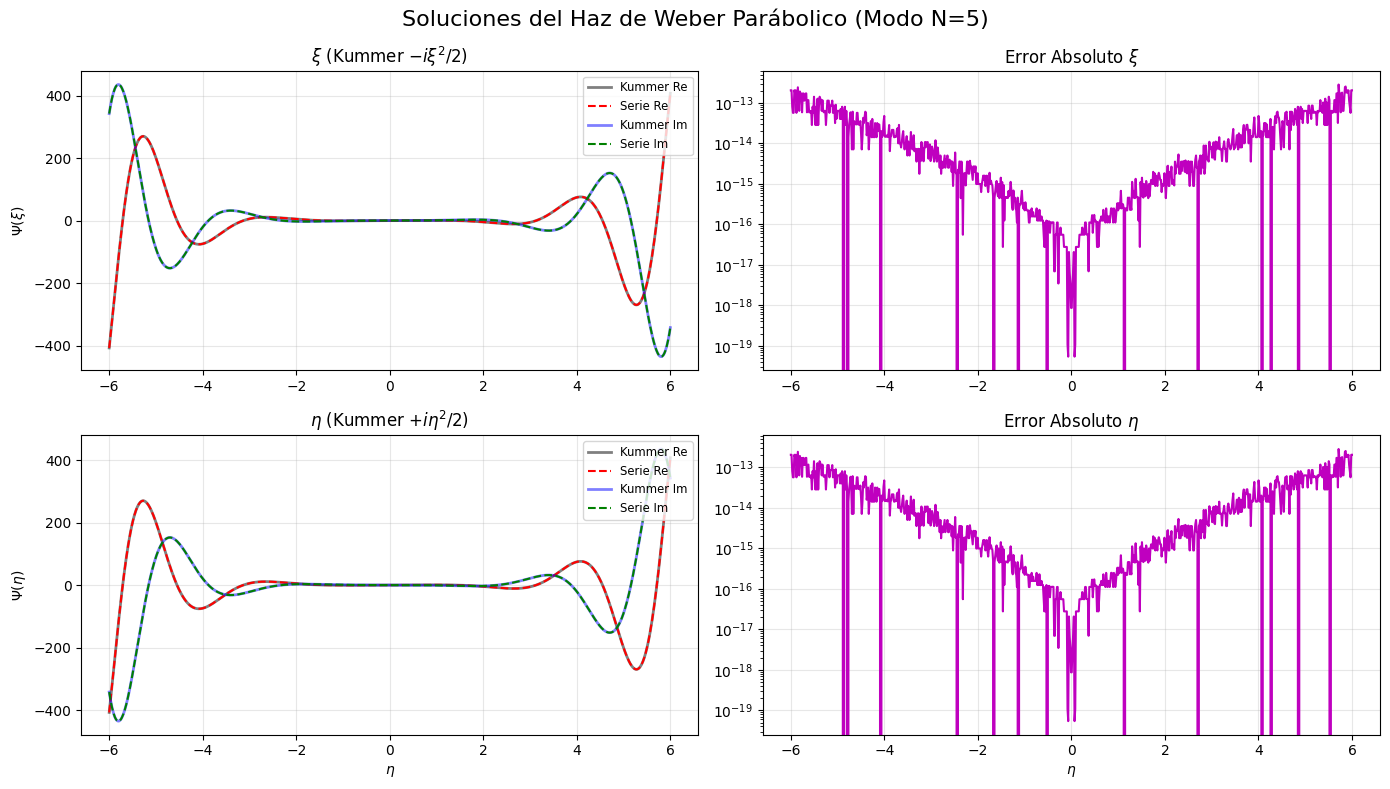

Parametro a (Weber): 5.5
Parametro A (Kummer par): -2.5
Ksi (ξ): rama par usa B=1/2; rama impar usa B=3/2 con factor ξ
Eta (η): rama par usa B=1/2; rama impar usa B=3/2 con factor η


In [ ]:
import numpy as np
import mpmath as mp
import matplotlib.pyplot as plt


def a_from_N_even(N: int) -> float:
    return 0.5*(2*N + 1)


def get_coeffs(N: int):
    c = [0j]*(2*N + 1)

    if N % 2 == 0:
        # Caso par: arranca en x^0
        c[0] = 1.0 + 0j
        c[1] = 0.0 + 0j
        rng = range(0, 2*N, 2)
    else:
        # Caso impar: arranca en x^1
        c[0] = 0.0 + 0j
        c[1] = 1.0 + 0j
        rng = range(1, 2*N-1, 2)

    for s in rng:
        num = -1j*(2*s + 1)/2.0 + 1j*(2*N + 1)/2.0
        den = (s + 2)*(s + 1)
        c[s+2] = (num/den)*c[s]

    return np.array(c, dtype=complex)

def series_even(x, N: int, beta_is_imag=True):
    x = np.asarray(x, dtype=float)
    c = get_coeffs(N)
    k = np.arange(len(c))[:, None]
    Xk = x[None, :] ** k
    poly = (c[:, None] * Xk).sum(axis=0)
    pref = np.exp((1j if beta_is_imag else 1.0) * 0.25 * x**2)
    return pref * poly


def kummer_xi_analytic(a_std: float, xi):
    xi = np.asarray(xi, dtype=float)

    # a_std = N + 1/2  =>  N = a_std - 1/2
    N_est = int(round(a_std - 0.5))

    if N_est % 2 == 0:
        # Par: M(A, 1/2, -i xi^2/2) * exp(+i xi^2/4)
        A = 0.25 - 0.5*a_std
        B = 0.5
        Z = -0.5j * xi**2
        f = np.vectorize(lambda z: complex(mp.hyp1f1(A, B, z)))
        return np.exp(0.25j * xi**2) * np.array(f(Z), dtype=complex)
    else:
        # Impar: xi * M(A+1/2, 3/2, -i xi^2/2) * exp(+i xi^2/4)
        A = 0.75 - 0.5*a_std   # = (0.25 - 0.5*a_std) + 1/2
        B = 1.5
        Z = -0.5j * xi**2
        f = np.vectorize(lambda z: complex(mp.hyp1f1(A, B, z)))
        return xi * np.exp(0.25j * xi**2) * np.array(f(Z), dtype=complex)

def kummer_eta_analytic(a_std: float, eta):
    eta = np.asarray(eta, dtype=float)

    N_est = int(round(a_std - 0.5))

    if N_est % 2 == 0:
        # Par: M(A, 1/2, +i eta^2/2) * exp(-i eta^2/4)
        A = 0.25 - 0.5*a_std
        B = 0.5
        Z = +0.5j * eta**2
        f = np.vectorize(lambda z: complex(mp.hyp1f1(A, B, z)))
        return np.exp(-0.25j * eta**2) * np.array(f(Z), dtype=complex)
    else:
        # Impar: eta * M(A+1/2, 3/2, +i eta^2/2) * exp(-i eta^2/4)
        A = 0.75 - 0.5*a_std
        B = 1.5
        Z = +0.5j * eta**2
        f = np.vectorize(lambda z: complex(mp.hyp1f1(A, B, z)))
        return eta * np.exp(-0.25j * eta**2) * np.array(f(Z), dtype=complex)


def comparar_componentes(N=6, span=(-6, 6), pts=800):
    a_std = a_from_N_even(N)
    u = np.linspace(span[0], span[1], pts)

    y_xi_num = series_even(u, N, beta_is_imag=True)
    y_xi_ana = kummer_xi_analytic(a_std, u)

    idx = len(u)//2
    if abs(y_xi_num[idx]) < 1e-14 or abs(y_xi_ana[idx]) < 1e-14:
        idx = min(idx + 1, len(u) - 1)

    scale_xi = y_xi_ana[idx] / y_xi_num[idx]
    y_xi_num_scaled = y_xi_num * scale_xi
    err_xi = np.abs(y_xi_ana - y_xi_num_scaled)

    y_eta_num = np.conj(series_even(u, N, beta_is_imag=True))
    y_eta_ana = kummer_eta_analytic(a_std, u)

    idx2 = len(u)//2
    if abs(y_eta_num[idx2]) < 1e-14 or abs(y_eta_ana[idx2]) < 1e-14:
        idx2 = min(idx2 + 1, len(u) - 1)

    scale_eta = y_eta_ana[idx2] / y_eta_num[idx2]
    y_eta_num_scaled = y_eta_num * scale_eta
    err_eta = np.abs(y_eta_ana - y_eta_num_scaled)

    # --- PLOT ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f"Soluciones del Haz de Weber Parábolico (Modo N={N})", fontsize=16)

    ax1 = axes[0, 0]
    ax1.set_title(r"$\xi$ (Kummer $-i\xi^2/2$)")
    ax1.plot(u, y_xi_ana.real, 'k-', lw=2, alpha=0.5, label="Kummer Re")
    ax1.plot(u, y_xi_num_scaled.real, 'r--', label="Serie Re")
    ax1.plot(u, y_xi_ana.imag, 'b-', lw=2, alpha=0.5, label="Kummer Im")
    ax1.plot(u, y_xi_num_scaled.imag, 'g--', label="Serie Im")
    ax1.legend(loc='upper right', fontsize='small')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylabel(r"$\Psi(\xi)$")

    ax2 = axes[0, 1]
    ax2.set_title(r"Error Absoluto $\xi$")
    ax2.plot(u, err_xi, 'm')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    ax3.set_title(r"$\eta$ (Kummer $+i\eta^2/2$)")
    ax3.plot(u, y_eta_ana.real, 'k-', lw=2, alpha=0.5, label="Kummer Re")
    ax3.plot(u, y_eta_num_scaled.real, 'r--', label="Serie Re")
    ax3.plot(u, y_eta_ana.imag, 'b-', lw=2, alpha=0.5, label="Kummer Im")
    ax3.plot(u, y_eta_num_scaled.imag, 'g--', label="Serie Im")
    ax3.legend(loc='upper right', fontsize='small')
    ax3.grid(True, alpha=0.3)
    ax3.set_xlabel(r"$\eta$")
    ax3.set_ylabel(r"$\Psi(\eta)$")

    ax4 = axes[1, 1]
    ax4.set_title(r"Error Absoluto $\eta$")
    ax4.plot(u, err_eta, 'm')
    ax4.set_yscale('log')
    ax4.grid(True, alpha=0.3)
    ax4.set_xlabel(r"$\eta$")

    plt.tight_layout()
    plt.show()

    print(f"Parametro a (Weber): {a_std}")
    print(f"Parametro A (Kummer par): {0.25 - 0.5*a_std}")
    print(f"Ksi (ξ): rama par usa B=1/2; rama impar usa B=3/2 con factor ξ")
    print(f"Eta (η): rama par usa B=1/2; rama impar usa B=3/2 con factor η")

comparar_componentes(N=5, span=(-6, 6))


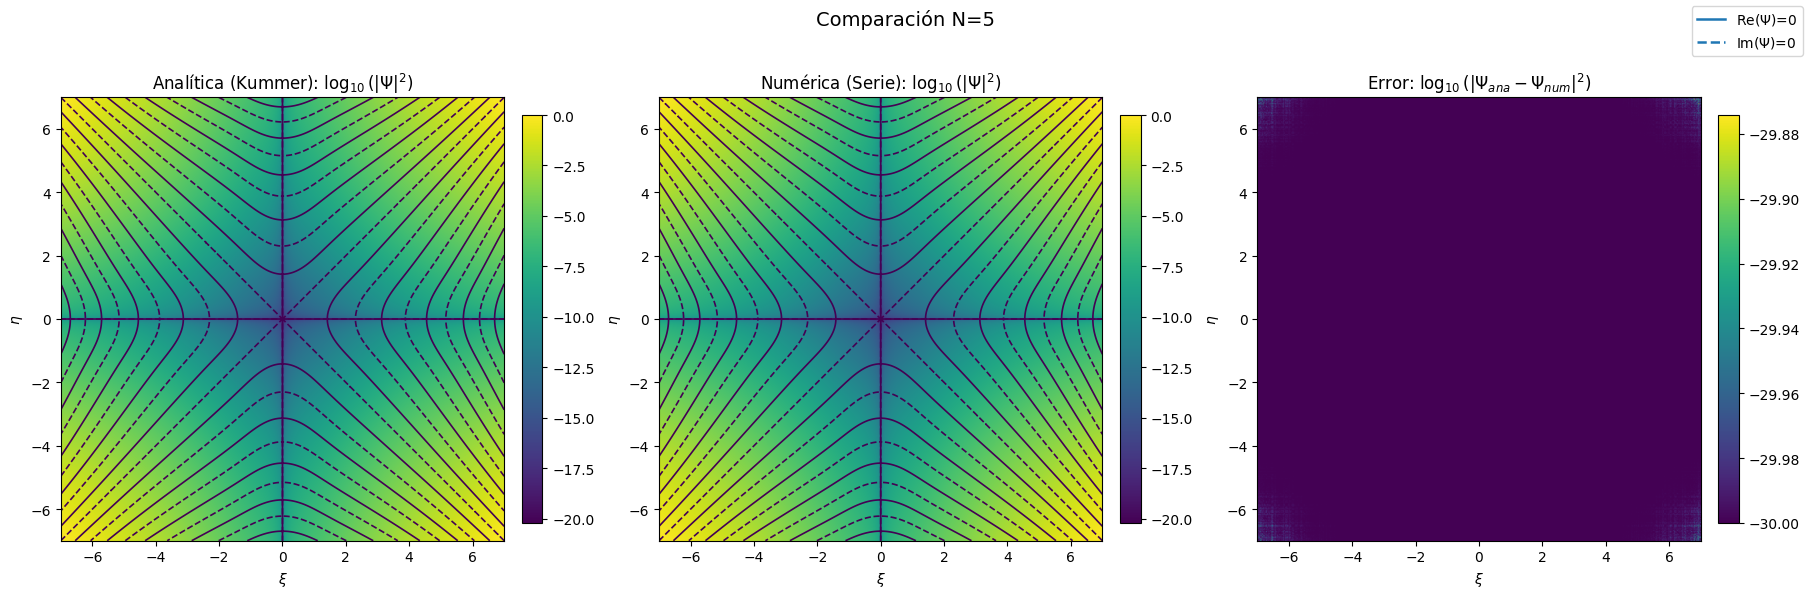

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def normalize_psi_2d(PSI, x, y, mode="l2"):
    if mode is None:
        return PSI
    I = np.abs(PSI)**2
    if mode == "l2":
        dx = float(x[1] - x[0])
        dy = float(y[1] - y[0])
        norm2 = I.sum() * dx * dy
        return PSI / np.sqrt(norm2) if norm2 > 0 else PSI
    if mode == "max":
        m = I.max()
        return PSI / np.sqrt(m) if m > 0 else PSI
    raise ValueError("mode must be 'l2', 'max', or None")

def build_PSI_2d(N=7, span=(-6, 6), pts=600, use="numeric"):
    a_std = a_from_N_even(N)
    xi = np.linspace(span[0], span[1], pts)
    eta = np.linspace(span[0], span[1], pts)

    if use == "analytic":
        psi_xi = kummer_xi_analytic(a_std, xi)
        psi_eta = kummer_eta_analytic(a_std, eta)

    elif use == "numeric":
        # xi
        y_xi_num = series_even(xi, N, beta_is_imag=True)
        y_xi_ana = kummer_xi_analytic(a_std, xi)
        idx = len(xi)//2
        if abs(y_xi_num[idx]) < 1e-14 or abs(y_xi_ana[idx]) < 1e-14:
            idx = min(idx + 1, len(xi) - 1)
        scale_xi = y_xi_ana[idx] / y_xi_num[idx]
        psi_xi = y_xi_num * scale_xi

        # eta
        y_eta_num = np.conj(series_even(eta, N, beta_is_imag=True))
        y_eta_ana = kummer_eta_analytic(a_std, eta)
        idx2 = len(eta)//2
        if abs(y_eta_num[idx2]) < 1e-14 or abs(y_eta_ana[idx2]) < 1e-14:
            idx2 = min(idx2 + 1, len(eta) - 1)
        scale_eta = y_eta_ana[idx2] / y_eta_num[idx2]
        psi_eta = y_eta_num * scale_eta

    else:
        raise ValueError("use must be 'analytic' or 'numeric'")

    PSI = psi_xi[:, None] * psi_eta[None, :]
    return xi, eta, PSI

def compare_wave2d(N=5, span=(-20, 20), pts=700, normalize="max",
                show_nodes=True, log_eps=1e-30):
    xi, eta, PSI_ana = build_PSI_2d(N, span, pts, use="analytic")
    _,  _,  PSI_num = build_PSI_2d(N, span, pts, use="numeric")

    # Normaliza ambos IGUAL 
    PSI_ana = normalize_psi_2d(PSI_ana, xi, eta, mode=normalize)
    PSI_num = normalize_psi_2d(PSI_num, xi, eta, mode=normalize)

    I_ana = np.abs(PSI_ana)**2
    I_num = np.abs(PSI_num)**2
    I_err = np.abs(PSI_ana - PSI_num)**2

    # Para que no se vea todo negro, log10(|.| + eps)
    Z_ana = np.log10(I_ana + log_eps).T
    Z_num = np.log10(I_num + log_eps).T
    Z_err = np.log10(I_err + log_eps).T

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

    ims = []
    ims.append(axes[0].imshow(Z_ana, origin="lower",
                              extent=(xi[0], xi[-1], eta[0], eta[-1]),
                              aspect="equal", interpolation="bilinear"))
    axes[0].set_title(r"Analítica (Kummer): $\log_{10}(|\Psi|^2)$")
    axes[0].set_xlabel(r"$\xi$"); axes[0].set_ylabel(r"$\eta$")

    ims.append(axes[1].imshow(Z_num, origin="lower",
                              extent=(xi[0], xi[-1], eta[0], eta[-1]),
                              aspect="equal", interpolation="bilinear"))
    axes[1].set_title(r"Numérica (Serie): $\log_{10}(|\Psi|^2)$")
    axes[1].set_xlabel(r"$\xi$"); axes[1].set_ylabel(r"$\eta$")

    ims.append(axes[2].imshow(Z_err, origin="lower",
                              extent=(xi[0], xi[-1], eta[0], eta[-1]),
                              aspect="equal", interpolation="bilinear"))
    axes[2].set_title(r"Error: $\log_{10}(|\Psi_{ana}-\Psi_{num}|^2)$")
    axes[2].set_xlabel(r"$\xi$"); axes[2].set_ylabel(r"$\eta$")

    for ax, im in zip(axes, ims):
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    if show_nodes:
       
        for ax, PSI, tag in [(axes[0], PSI_ana, "Kummer"),
                             (axes[1], PSI_num, "Serie")]:
            ax.contour(xi, eta, PSI.real.T, levels=[0], linewidths=1.2, linestyles='-')
            ax.contour(xi, eta, PSI.imag.T, levels=[0], linewidths=1.2, linestyles='--')

        
        h1 = Line2D([0],[0], linestyle='-',  linewidth=1.8, label=r"Re($\Psi$)=0")
        h2 = Line2D([0],[0], linestyle='--', linewidth=1.8, label=r"Im($\Psi$)=0")
        fig.legend(handles=[h1, h2], loc="upper right")

    fig.suptitle(f"Comparación N={N}", fontsize=14)
    plt.show()

compare_wave2d(N=5, span=(-7, 7), pts=700, normalize="max", show_nodes=True)


In [ ]:
``